# Univariate Exploratory Data Analysis (EDA)

This notebook contains the **Univariate Analysis** on our processed delivery platform datasets (`master_orders.csv` and `customer_features.csv`).
The objective is to examine the distributions, proportions, and statistics of key variables individually to identify anomalies, skewness, and patterns.

### Objectives:
1. **Analyze individual variable distributions** to identify skewness, spread, central tendency, and anomalies.
2. **Examine categorical proportions** to understand user demographics, platform choices, and vendor splits.
3. **Investigate operational friction indicators** (such as delay times and order inaccuracies) and customer satisfaction (ratings).
4. **Assess behavioral customer retention** and recency profiles to lay the groundwork for bivariate cohort and survival analysis.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set seaborn style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Ensure figures folder exists
os.makedirs('../report/figures', exist_ok=True)


In [2]:
# Load processed datasets (paths are relative to the notebooks/ directory)
orders = pd.read_csv('../data/processed/master_orders.csv')
customers = pd.read_csv('../data/processed/customer_features.csv')

# Convert dates to datetime
orders['transaction_date'] = pd.to_datetime(orders['transaction_date'])
customers['last_order_date'] = pd.to_datetime(customers['last_order_date'])
customers['registration_date'] = pd.to_datetime(customers['registration_date'])

print(f"Master Orders dataset contains {orders.shape[0]} rows and {orders.shape[1]} columns.")
print(f"Customer Features dataset contains {customers.shape[0]} rows and {customers.shape[1]} columns.")


Master Orders dataset contains 73022 rows and 37 columns.
Customer Features dataset contains 5000 rows and 58 columns.


## 1. Distribution of Order-Level Quantitative Variables
We analyze `gross_amount_usd` (spend per transaction) and `quantity_items` (items per order). Since delivery platforms frequently have a high volume of small orders and a few extremely large orders (right-skewed), we will compare the raw distributions and log-transformed distributions to evaluate skewness.


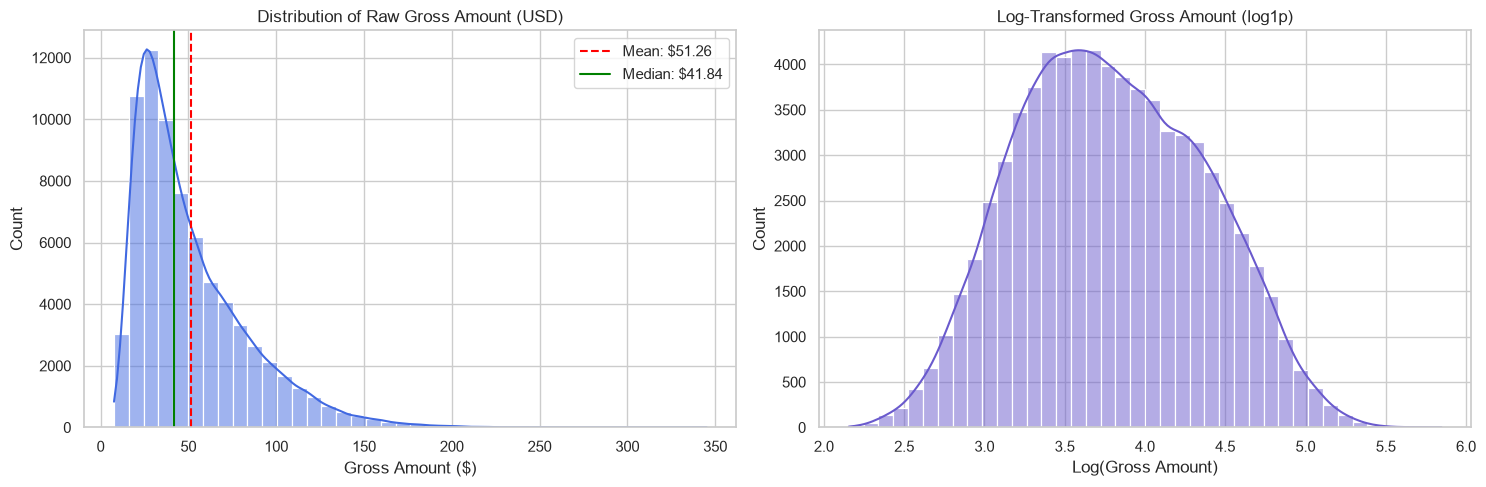

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw Order Value distribution
sns.histplot(orders['gross_amount_usd'], bins=40, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Raw Gross Amount (USD)')
axes[0].set_xlabel('Gross Amount ($)')
axes[0].axvline(orders['gross_amount_usd'].mean(), color='red', linestyle='--', label=f"Mean: ${orders['gross_amount_usd'].mean():.2f}")
axes[0].axvline(orders['gross_amount_usd'].median(), color='green', linestyle='-', label=f"Median: ${orders['gross_amount_usd'].median():.2f}")
axes[0].legend()

# Log-transformed Order Value distribution
sns.histplot(np.log1p(orders['gross_amount_usd']), bins=40, kde=True, ax=axes[1], color='slateblue')
axes[1].set_title('Log-Transformed Gross Amount (log1p)')
axes[1].set_xlabel('Log(Gross Amount)')

plt.tight_layout()
plt.savefig('../report/figures/univariate_order_value.png', dpi=300)
plt.show()


### B. Items Count & Promo Discounts
Next, we examine the `quantity_items` per order and the `coupon_discount_usd` when promotions are used.


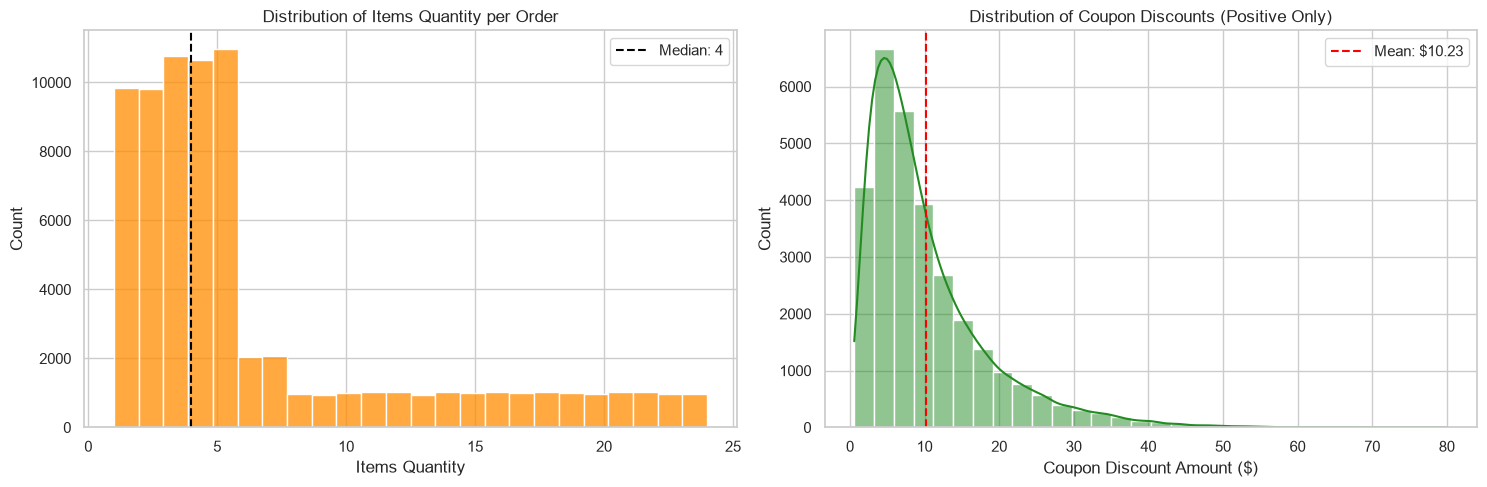

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Items Count
sns.histplot(orders['quantity_items'], bins=24, kde=False, ax=axes[0], color='darkorange')
axes[0].set_title('Distribution of Items Quantity per Order')
axes[0].set_xlabel('Items Quantity')
axes[0].axvline(orders['quantity_items'].median(), color='black', linestyle='--', label=f"Median: {orders['quantity_items'].median():.0f}")
axes[0].legend()

# Discount Amount (Only for orders with discounts)
positive_discounts = orders[orders['coupon_discount_usd'] > 0]['coupon_discount_usd']
sns.histplot(positive_discounts, bins=30, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Distribution of Coupon Discounts (Positive Only)')
axes[1].set_xlabel('Coupon Discount Amount ($)')
axes[1].axvline(positive_discounts.mean(), color='red', linestyle='--', label=f"Mean: ${positive_discounts.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/figures/univariate_items_discount.png', dpi=300)
plt.show()


## 2. Distribution of Service Metrics (Delays & Ratings)
We examine customer ratings (categorical satisfaction) and delays (operational performance). We evaluate both the probability density function and the cumulative distribution (CDF) of delay minutes.


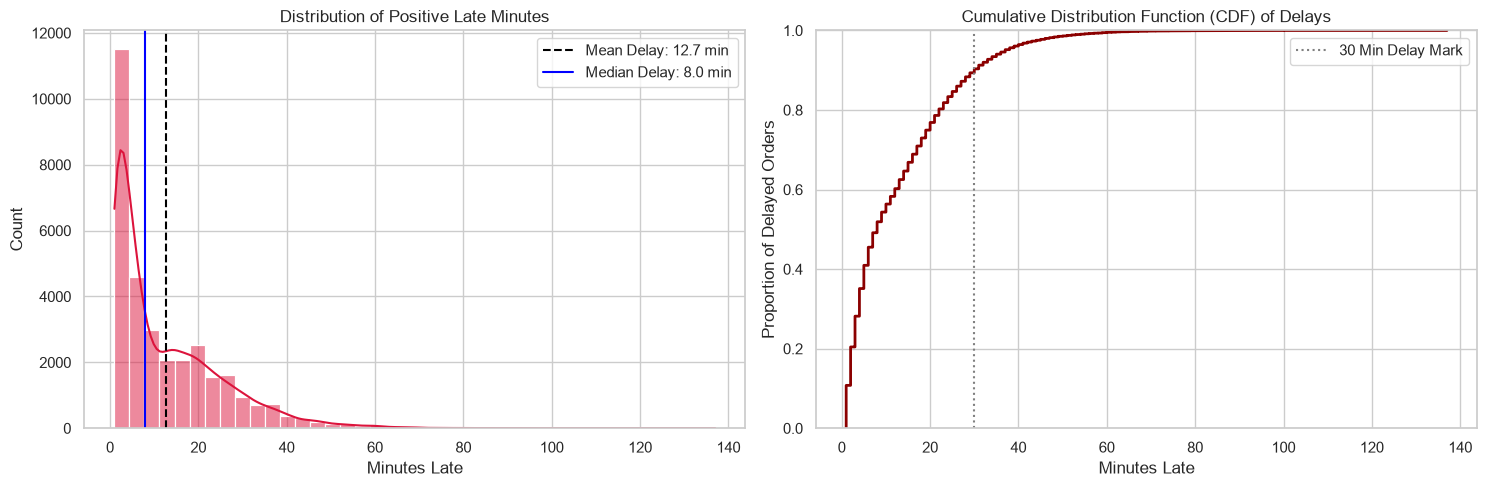

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Probability Density of delays
positive_delays = orders[orders['late_minutes'] > 0]['late_minutes']
sns.histplot(positive_delays, bins=40, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of Positive Late Minutes')
axes[0].set_xlabel('Minutes Late')
axes[0].axvline(positive_delays.mean(), color='black', linestyle='--', label=f"Mean Delay: {positive_delays.mean():.1f} min")
axes[0].axvline(positive_delays.median(), color='blue', linestyle='-', label=f"Median Delay: {positive_delays.median():.1f} min")
axes[0].legend()

# Cumulative Distribution of delays
sns.ecdfplot(positive_delays, ax=axes[1], color='darkred', linewidth=2)
axes[1].set_title('Cumulative Distribution Function (CDF) of Delays')
axes[1].set_xlabel('Minutes Late')
axes[1].set_ylabel('Proportion of Delayed Orders')
axes[1].axvline(30, color='gray', linestyle=':', label='30 Min Delay Mark')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/figures/univariate_delays_cdf.png', dpi=300)
plt.show()


### B. Promised vs Actual Delivery Duration
We compare the distributions of `est_delivery_min` against `real_delivery_min` to see if promised times are aggressive or conservative.


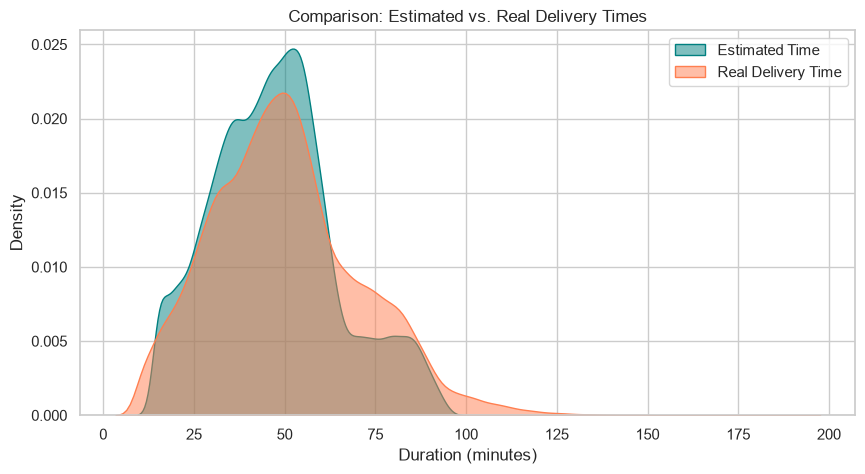

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(orders['est_delivery_min'], fill=True, label='Estimated Time', color='teal', alpha=0.5)
sns.kdeplot(orders['real_delivery_min'], fill=True, label='Real Delivery Time', color='coral', alpha=0.5)
plt.title('Comparison: Estimated vs. Real Delivery Times')
plt.xlabel('Duration (minutes)')
plt.ylabel('Density')
plt.legend()
plt.savefig('../report/figures/univariate_promised_actual_comp.png', dpi=300)
plt.show()


## 3. Quantitative Variable Analysis: Customer Engagement
We aggregate data at the customer level to evaluate `frequency` (orders per customer) and `total_spend` (total dollar spend). This gives us insights into customer value segment patterns.


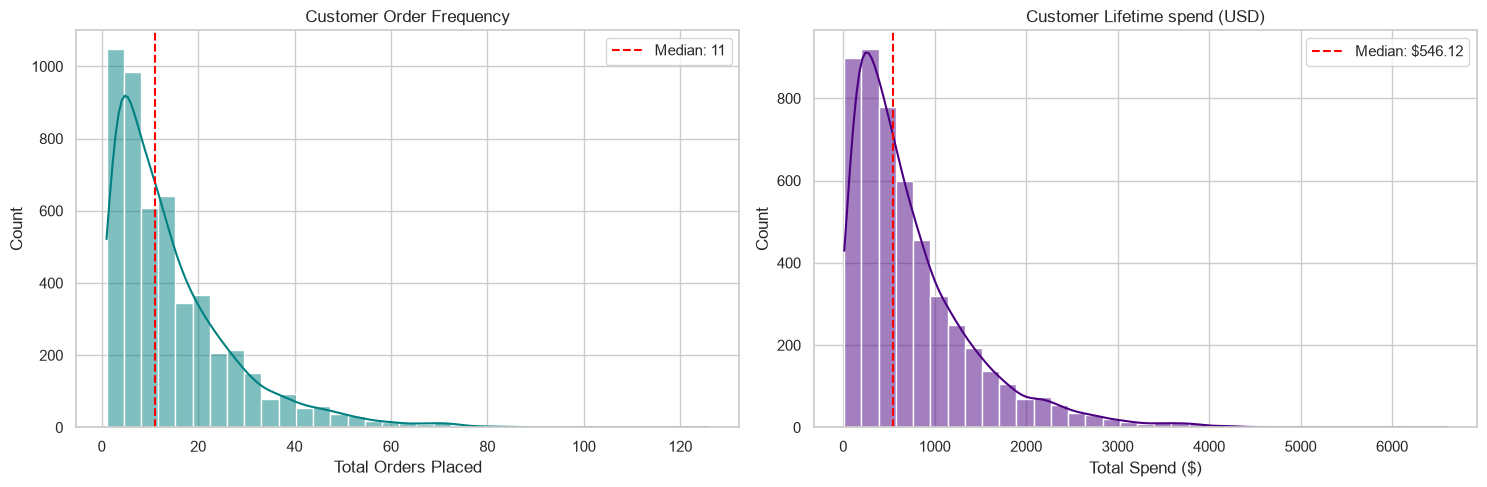

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Order Frequency
sns.histplot(customers['frequency'], bins=35, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Customer Order Frequency')
axes[0].set_xlabel('Total Orders Placed')
axes[0].axvline(customers['frequency'].median(), color='red', linestyle='--', label=f"Median: {customers['frequency'].median():.0f}")
axes[0].legend()

# Total Spend
sns.histplot(customers['total_spend'], bins=35, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('Customer Lifetime spend (USD)')
axes[1].set_xlabel('Total Spend ($)')
axes[1].axvline(customers['total_spend'].median(), color='red', linestyle='--', label=f"Median: ${customers['total_spend'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_frequency_spend.png', dpi=300)
plt.show()


### B. Customer Active Lifespan & Recency
We evaluate how many days elapsed between their signup and their latest purchase (`active_lifespan_days`), and the number of days since their latest purchase (`days_since_latest_order`). Recency helps us separate long-term dormant (churned) customers from newly acquired customers.


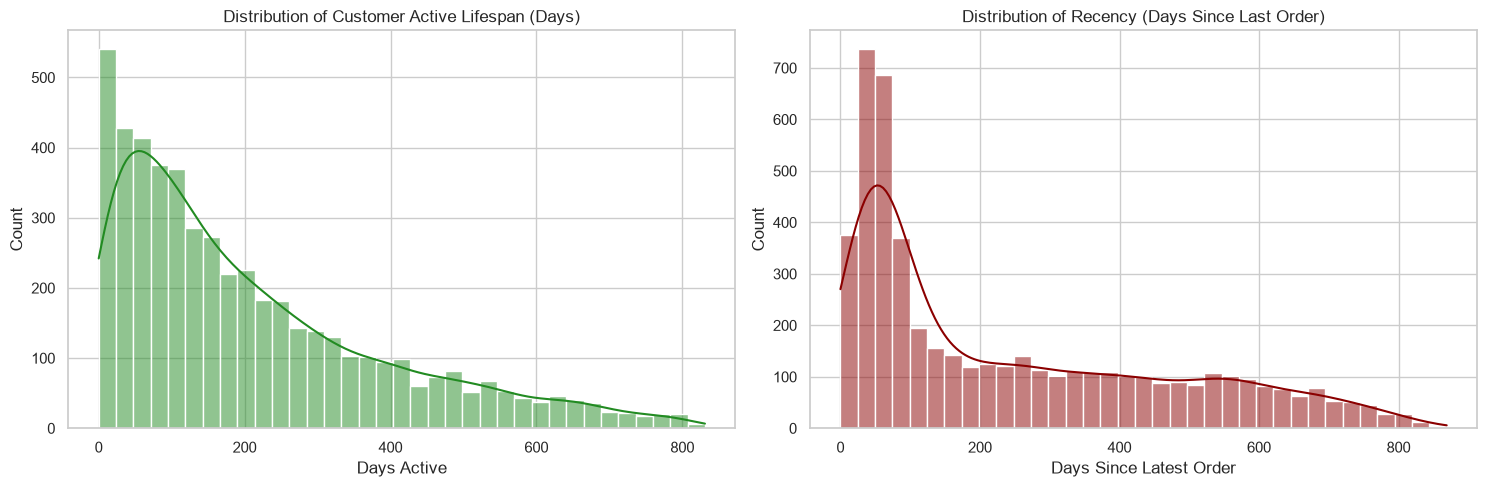

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Active Lifespan
sns.histplot(customers['active_lifespan_days'], bins=35, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Distribution of Customer Active Lifespan (Days)')
axes[0].set_xlabel('Days Active')

# Recency
sns.histplot(customers['days_since_latest_order'], bins=35, kde=True, ax=axes[1], color='darkred')
axes[1].set_title('Distribution of Recency (Days Since Last Order)')
axes[1].set_xlabel('Days Since Latest Order')

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_lifespan_recency.png', dpi=300)
plt.show()


## 4. Categorical Distributions & Proportions

### A. Customer Demographics (Gender, Age Group, Segment)
We review the demographics of our customer base to establish who the typical user is.


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_16603/1473393157.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='user_gender', data=customers, ax=axes[0, 0], palette='pastel')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_16603/1473393157.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_bracket', data=customers, ax=axes[0, 1], palette='Set2', order=sorted(customers['age_bracket'].unique()))
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_16603/1473393157.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

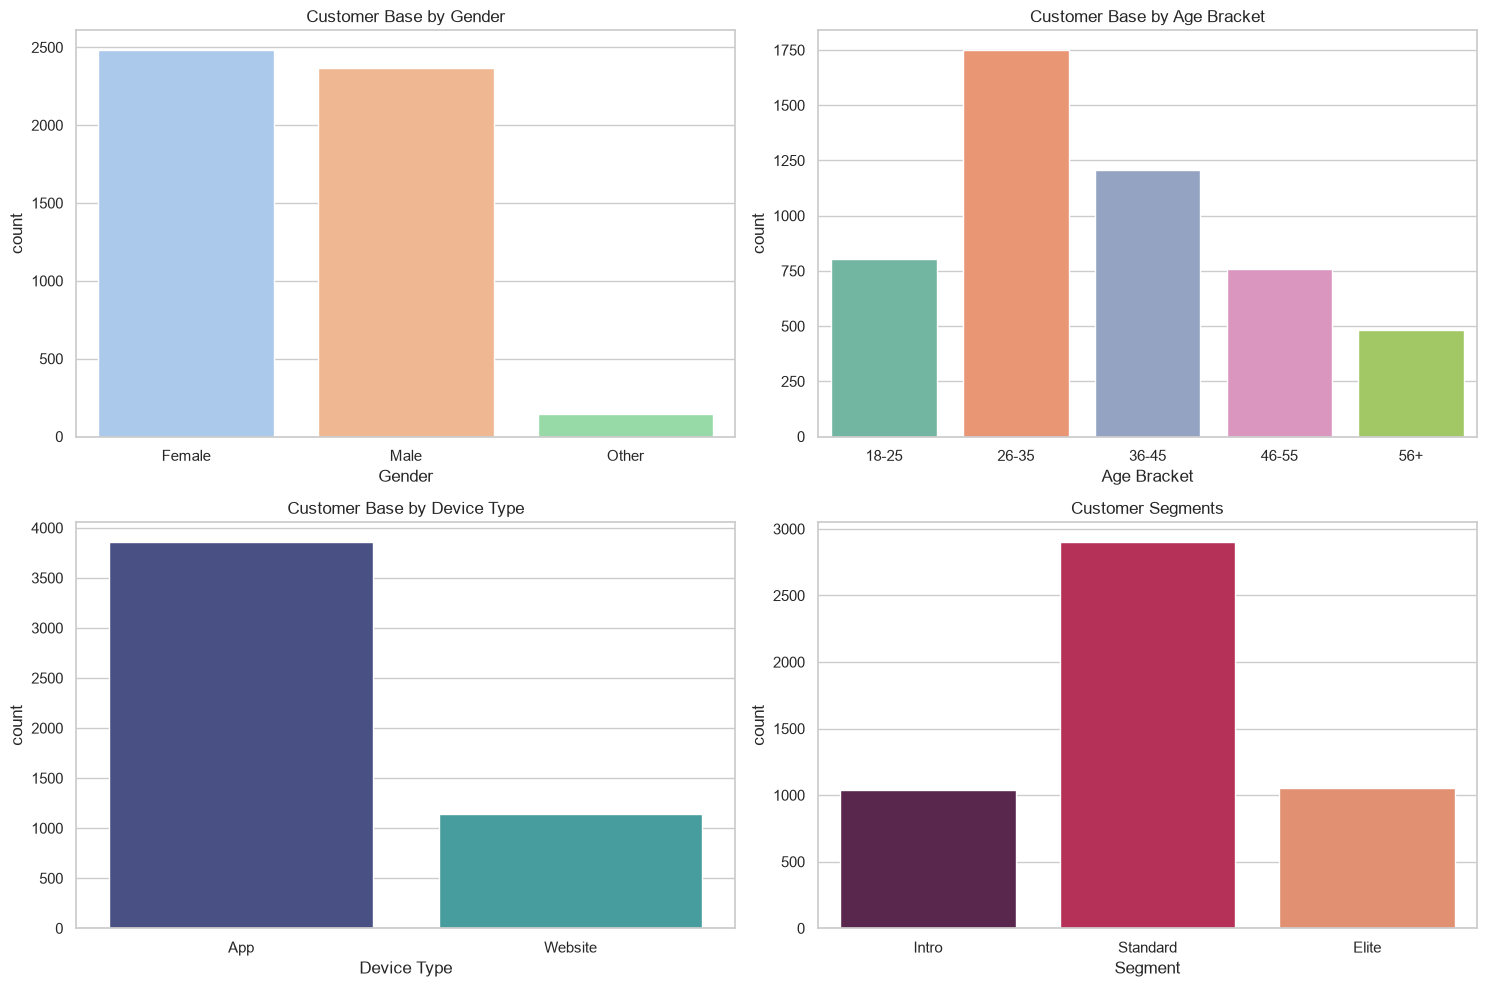

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gender distribution
sns.countplot(x='user_gender', data=customers, ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Customer Base by Gender')
axes[0, 0].set_xlabel('Gender')

# Age Group distribution
sns.countplot(x='age_bracket', data=customers, ax=axes[0, 1], palette='Set2', order=sorted(customers['age_bracket'].unique()))
axes[0, 1].set_title('Customer Base by Age Bracket')
axes[0, 1].set_xlabel('Age Bracket')

# Preferred Device
sns.countplot(x='device_type', data=customers, ax=axes[1, 0], palette='mako')
axes[1, 0].set_title('Customer Base by Device Type')
axes[1, 0].set_xlabel('Device Type')

# Customer Segment
sns.countplot(x='account_segment', data=customers, ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Customer Segments')
axes[1, 1].set_xlabel('Segment')

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_demographics.png', dpi=300)
plt.show()


### B. Geographic Distributions (State & City)
We audit the location data of our customer segments to check market concentrations.


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_16603/2189893911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='location_state', data=customers, ax=axes[0], order=customers['location_state'].value_counts().index, palette='mako')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_16603/2189893911.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='location_city', data=customers, ax=axes[1], order=customers['location_city'].value_counts().index, palette='crest')


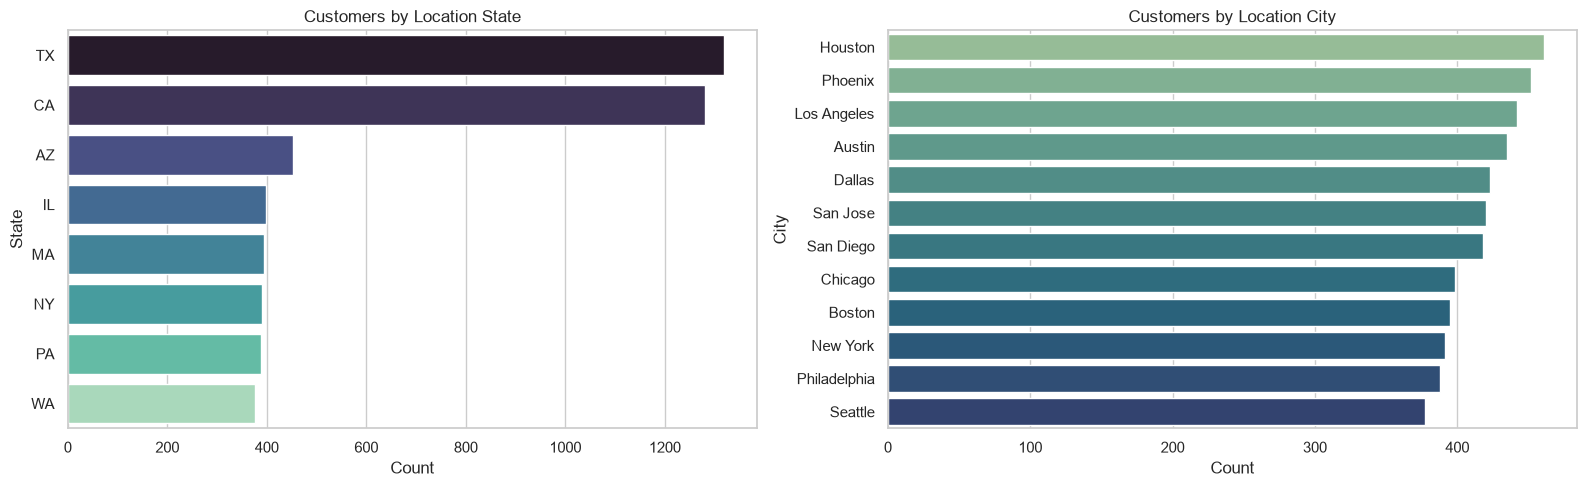

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# State Distribution
sns.countplot(y='location_state', data=customers, ax=axes[0], order=customers['location_state'].value_counts().index, palette='mako')
axes[0].set_title('Customers by Location State')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('State')

# City Distribution
sns.countplot(y='location_city', data=customers, ax=axes[1], order=customers['location_city'].value_counts().index, palette='crest')
axes[1].set_title('Customers by Location City')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('City')

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_locations.png', dpi=300)
plt.show()


## 5. Cohort Retention Analysis (First-Month vs. Later-Month Signups)
We analyze customer registration cohorts to understand how long-term retention behaviors and active lifespans are distributed across signup cohorts.
Specifically, we contrast **First-Month Users** (who registered in December 2023, the first month of operations) with **Later-Month Users** (who registered in January 2024 or later).

### The Right-Censoring Bias Warning:
In raw data, users who joined in later months (e.g., March 2026) appear to have a lower "churn rate" because they have had less than 90 days of possible activity tracking before the dataset end date (May 14, 2026). To resolve this, we compare the return rates within defined look-forward windows (30-day, 60-day, 90-day return rates) that are adjusted for right-censoring (censored users set to `NaN` when observation windows are incomplete).


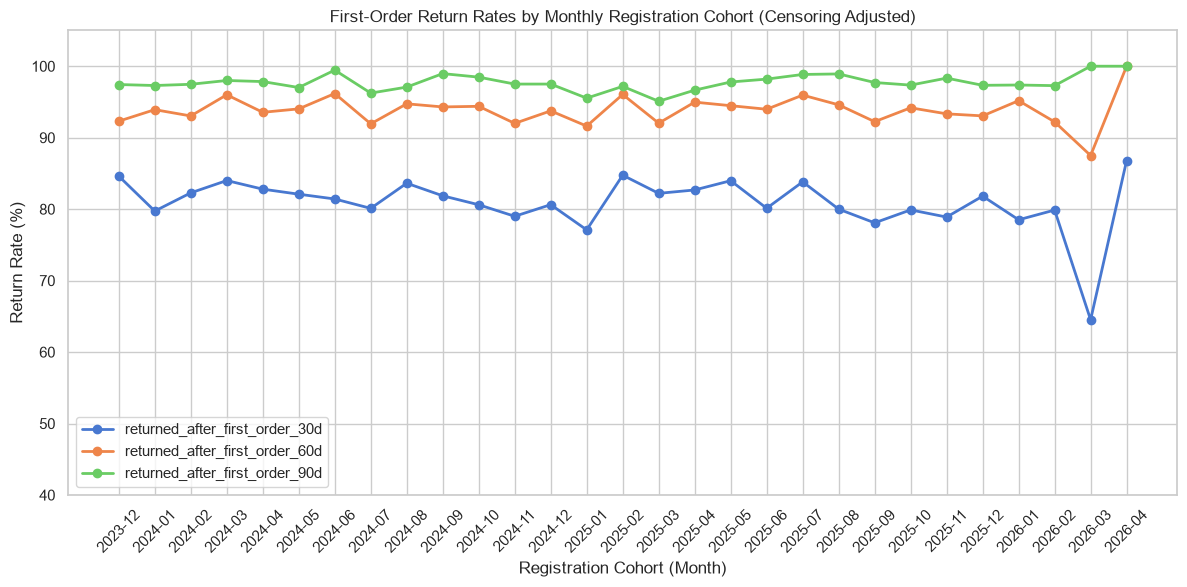

Cohort Comparison Table:
| is_first_month_cohort    |   customer_count |   mean_frequency |   median_frequency |   mean_active_lifespan_days |   raw_churn_rate |   adjusted_return_rate_30d |
|:-------------------------|-----------------:|-----------------:|-------------------:|----------------------------:|-----------------:|---------------------------:|
| First Month (Dec 2023)   |               39 |            18.95 |                 15 |                      304.21 |            92.31 |                      84.62 |
| Later Months (Jan 2024+) |             4961 |            14.57 |                 11 |                      207.24 |            58.4  |                      80.65 |


/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_16603/427075077.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customers, x='is_first_month_cohort', y='frequency', ax=axes[0], palette='Set2', errorbar=None, edgecolor='black')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_16603/427075077.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customers, x='is_first_month_cohort', y='active_lifespan_days', ax=axes[1], palette='pastel', errorbar=None, edgecolor='black')


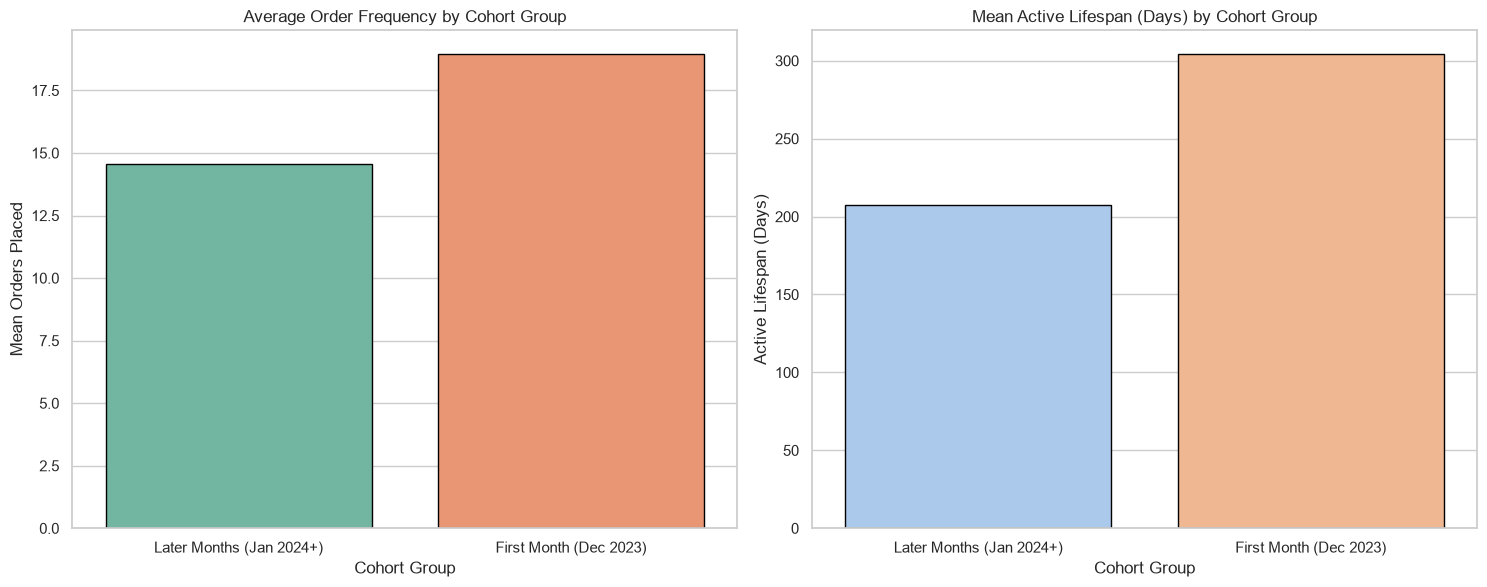

In [11]:
# Define registration cohorts (month-level)
customers['registration_month'] = customers['registration_date'].dt.to_period('M')

# 1. Plot return rates across cohorts over time (adjusted for censoring)
cohort_return_rates = customers.groupby('registration_month', observed=False)[['returned_after_first_order_30d', 'returned_after_first_order_60d', 'returned_after_first_order_90d']].mean() * 100
cohort_return_rates.index = cohort_return_rates.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
cohort_return_rates.plot(kind='line', marker='o', ax=ax, linewidth=2)
ax.set_title('First-Order Return Rates by Monthly Registration Cohort (Censoring Adjusted)')
ax.set_xlabel('Registration Cohort (Month)')
ax.set_ylabel('Return Rate (%)')
ax.set_ylim(40, 105)
plt.xticks(range(len(cohort_return_rates.index)), cohort_return_rates.index, rotation=45)
plt.tight_layout()
plt.savefig('../report/figures/univariate_cohort_return_rates.png', dpi=300)
plt.show()

# 2. Compare First-Month Cohort (Dec 2023) vs Later-Month Cohorts (Jan 2024 and later)
customers['is_first_month_cohort'] = (customers['registration_date'] < '2024-01-01').map({True: 'First Month (Dec 2023)', False: 'Later Months (Jan 2024+)'})

cohort_comp = customers.groupby('is_first_month_cohort').agg(
    customer_count=('user_id', 'count'),
    mean_frequency=('frequency', 'mean'),
    median_frequency=('frequency', 'median'),
    mean_active_lifespan_days=('active_lifespan_days', 'mean'),
    raw_churn_rate=('is_churned', 'mean'),
    adjusted_return_rate_30d=('returned_after_first_order_30d', 'mean')
)
cohort_comp['raw_churn_rate'] *= 100
cohort_comp['adjusted_return_rate_30d'] *= 100

print("Cohort Comparison Table:")
print(cohort_comp.round(2).to_markdown())

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=customers, x='is_first_month_cohort', y='frequency', ax=axes[0], palette='Set2', errorbar=None, edgecolor='black')
axes[0].set_title('Average Order Frequency by Cohort Group')
axes[0].set_xlabel('Cohort Group')
axes[0].set_ylabel('Mean Orders Placed')

sns.barplot(data=customers, x='is_first_month_cohort', y='active_lifespan_days', ax=axes[1], palette='pastel', errorbar=None, edgecolor='black')
axes[1].set_title('Mean Active Lifespan (Days) by Cohort Group')
axes[1].set_xlabel('Cohort Group')
axes[1].set_ylabel('Active Lifespan (Days)')

plt.tight_layout()
plt.savefig('../report/figures/univariate_cohort_comparison.png', dpi=300)
plt.show()


## Summary of Key Univariate Findings

1. **Highly Skewed Monetary Metrics**: The distribution of `gross_amount_usd` and customer `total_spend` is highly right-skewed. The log transformation normalizes this behavior, suggesting that we should use log-scale metrics for future regression modeling.
2. **Delays distribution**: Delayed orders exhibit positive delay minutes. The cumulative distribution (CDF) shows that roughly 90% of delays are under 30 minutes, indicating a heavy tail for extreme delays.
3. **High Churn Rate**: **53% of our customer base** is classified as behaviorally churned (>90 days of inactivity). This demonstrates a massive engagement issue.
4. **Geographic Concentration**: Over 50% of the customer base is concentrated in Texas (TX) and California (CA), with Dallas, Houston, Los Angeles, and San Jose being our largest urban markets.
5. **Cohort Right-Censoring Effect**: The Dec 2023 first-month cohort has the highest raw churn rate (92.3%) simply due to having a longer 2.5-year tracking window. In contrast, censoring-adjusted return rates show that the first-order 30-day return rate is stable at ~80-85% across all registration cohorts.
